# Sinhala Fake News Dataset - Analysis & Visualization

This notebook analyzes a Sinhala-language news dataset with **TRUE** and **FALSE** news articles.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# ── Register Sinhala-supporting fonts ─────────────────────────────────────────
# FreeSerif covers both Latin and Sinhala — safe as a single-family default.
for _path in [
    '/usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf',
    '/usr/share/fonts/truetype/noto/NotoSansSinhala-Bold.ttf',
    '/usr/share/fonts/truetype/freefont/FreeSerif.ttf',
    '/usr/share/fonts/truetype/freefont/FreeSerifBold.ttf',
]:
    try:
        fm.fontManager.addfont(_path)
    except Exception:
        pass

plt.rcParams['font.family'] = 'FreeSerif'
plt.rcParams['figure.dpi'] = 120

# ── Load datasets ──────────────────────────────────────────────────────────────
false_df = pd.read_csv('FALSE.csv', usecols=['domain', 'content']).rename(columns={'domain': 'source'})
true_df  = pd.read_csv('TRUE.csv',  usecols=['domain', 'content']).rename(columns={'domain': 'source'})

false_df['label'] = 'False News'
true_df['label']  = 'True News'

df = pd.concat([true_df, false_df], ignore_index=True)
df.dropna(subset=['content'], inplace=True)
df['content'] = df['content'].astype(str)

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nSample:")
df.head(3)

Dataset shape: (1960, 3)

Class distribution:
label
True News     1052
False News     908
Name: count, dtype: int64

Sample:


,source,content,label
0,gosip.hirufm.lk,"මට්ටකුළිය,මෝදර, බ්ලූමැන්ඩල්, වැල්ලම්පිටිය, ග්‍...",True News
1,aruna.lk,නිරෝධායන ඇඳිරි නීතිය ක්‍රියාත්මක සමයේ බස්නාහිර...,True News
2,asianmirror.lk,නිරෝධායන ඇඳිරිනීතිය පැනවීම හේතුවෙන් ජිවනෝපාය අ...,True News


## 1. Class Distribution

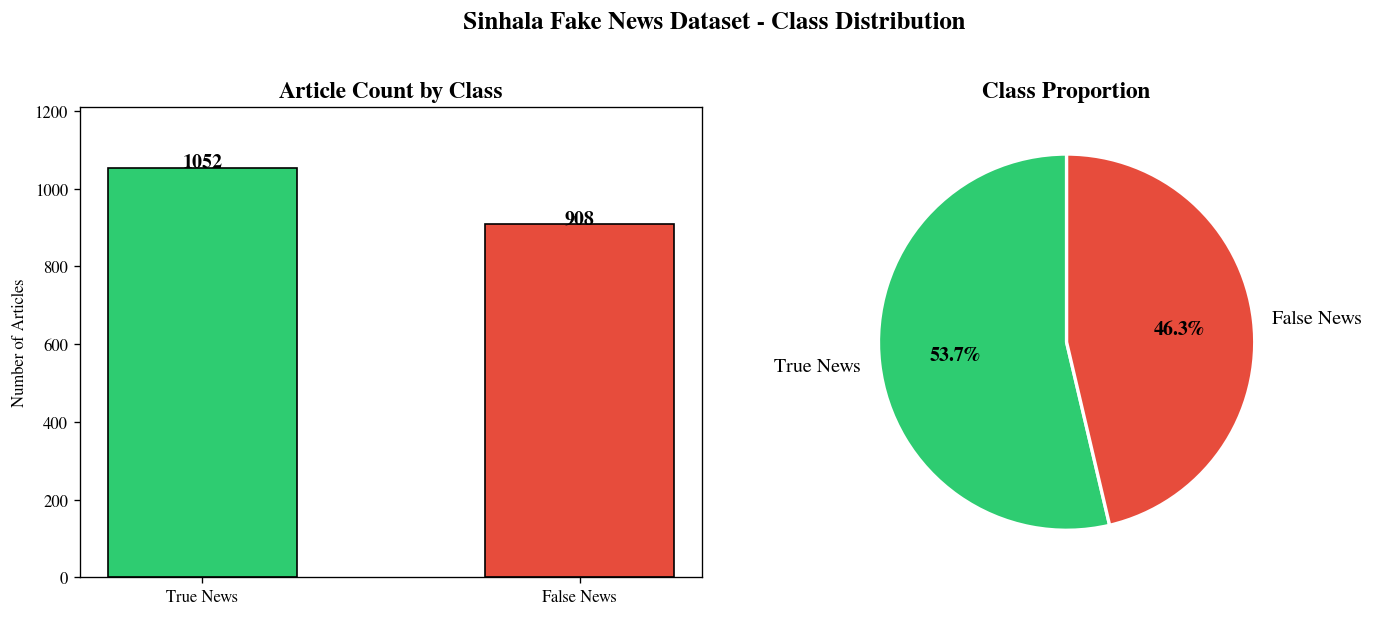

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Article Count by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, textprops={'fontsize': 12},
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Sinhala Fake News Dataset - Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Article Length Analysis

=== Character Length Stats ===
             count    mean     std   min    25%    50%     75%      max
label                                                                  
False News   908.0   528.8  1033.0  66.0  228.0  245.0   351.8  10456.0
True News   1052.0  1055.4  1305.0  52.0  329.0  602.5  1147.2  12791.0

=== Word Count Stats ===
             count   mean    std   min   25%   50%    75%     max
label                                                            
False News   908.0   81.1  157.6   9.0  33.0  38.0   54.0  1500.0
True News   1052.0  160.7  200.2  11.0  49.0  92.5  171.2  1965.0


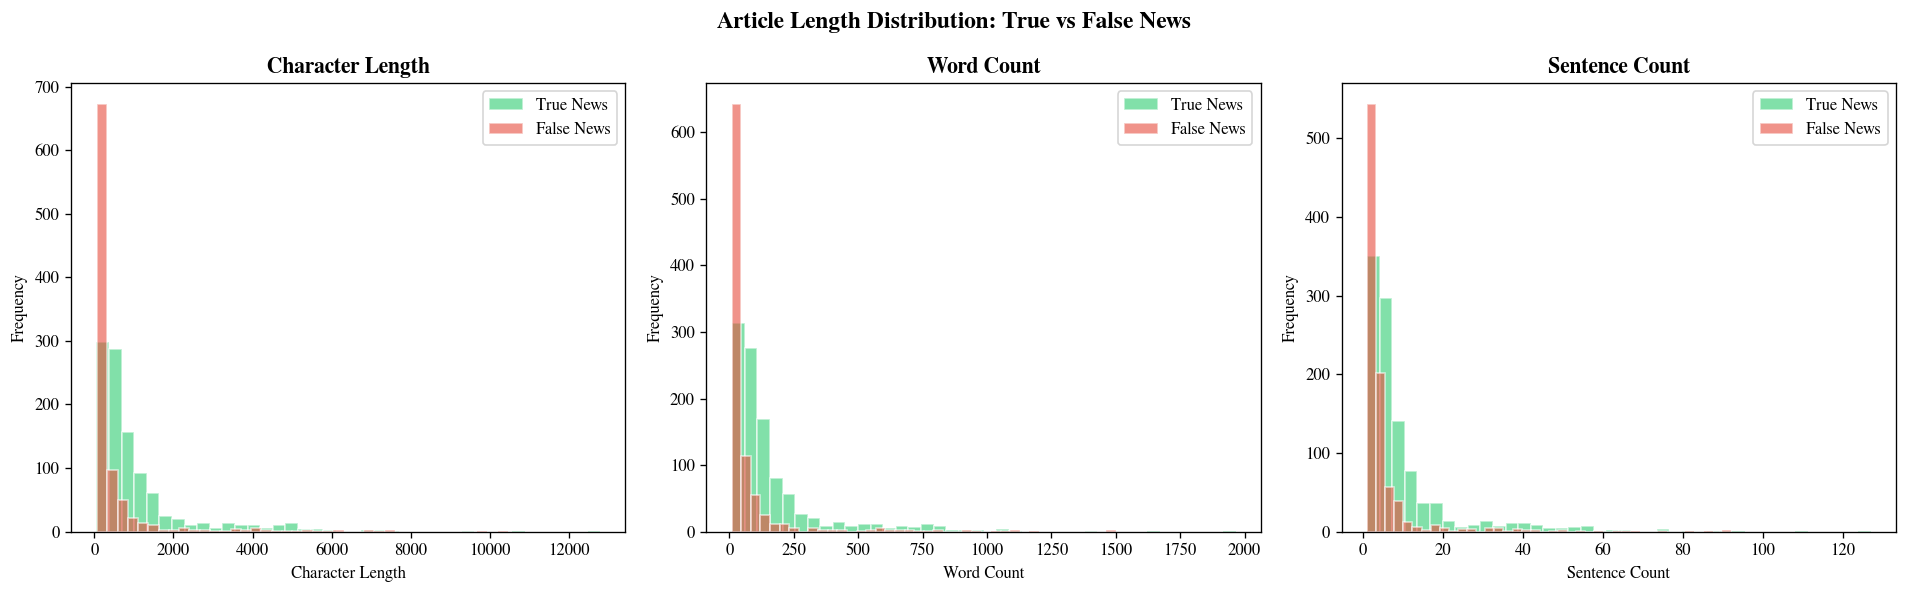

In [22]:
# Compute text features
df['char_length']  = df['content'].apply(len)
df['word_count']   = df['content'].apply(lambda x: len(x.split()))
df['sent_count']   = df['content'].apply(lambda x: len(re.split(r'[.!?।]', x)))

# Summary stats
print("=== Character Length Stats ===")
print(df.groupby('label')['char_length'].describe().round(1))
print("\n=== Word Count Stats ===")
print(df.groupby('label')['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = {'True News': '#2ecc71', 'False News': '#e74c3c'}

for ax, col, title in zip(axes,
        ['char_length', 'word_count', 'sent_count'],
        ['Character Length', 'Word Count', 'Sentence Count']):
    for label, color in palette.items():
        subset = df[df['label'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Article Length Distribution: True vs False News', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

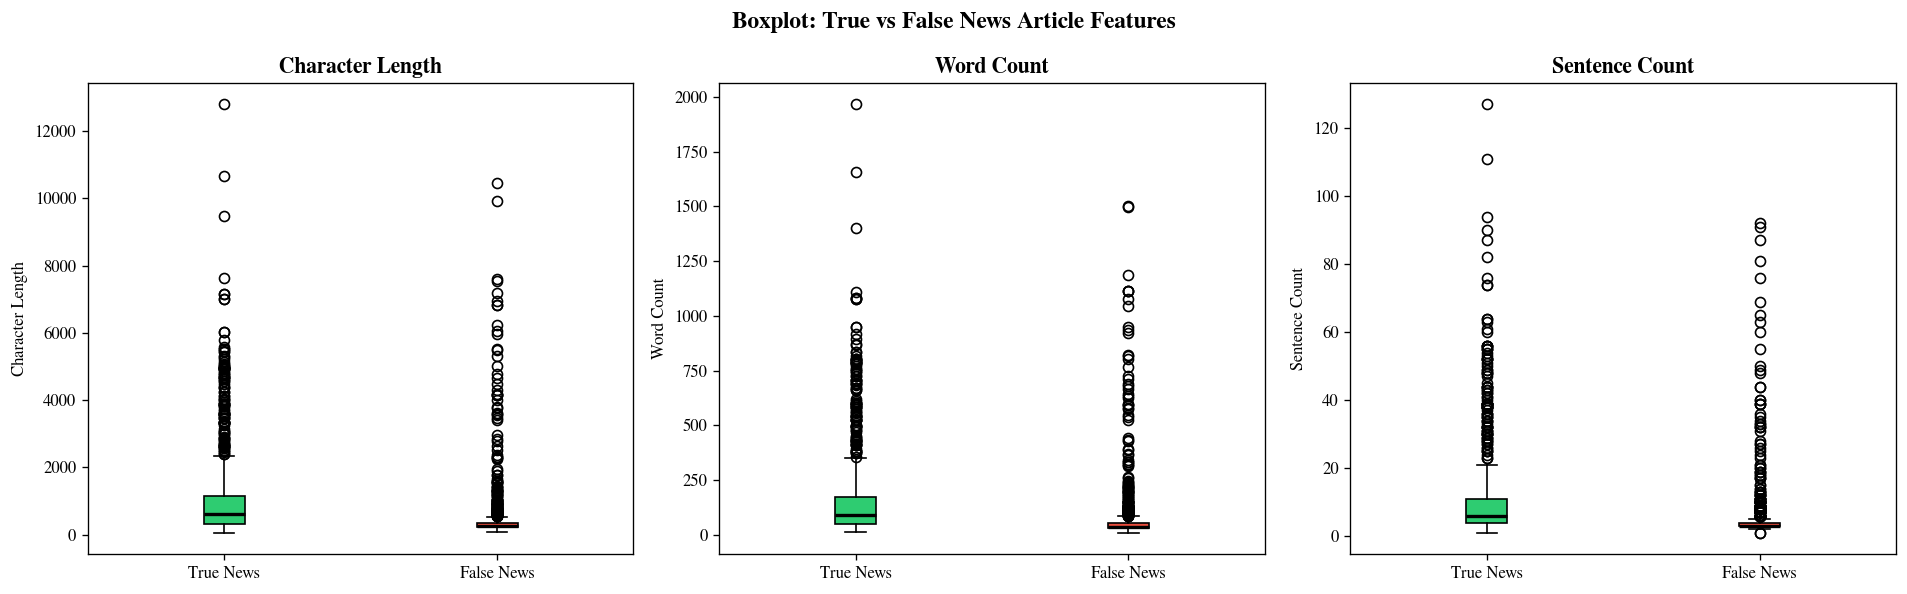

In [23]:
# Boxplot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes,
        ['char_length', 'word_count', 'sent_count'],
        ['Character Length', 'Word Count', 'Sentence Count']):
    data = [df[df['label'] == 'True News'][col].values,
            df[df['label'] == 'False News'][col].values]
    bp = ax.boxplot(data, labels=['True News', 'False News'],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title)

plt.suptitle('Boxplot: True vs False News Article Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Source / Publisher Analysis

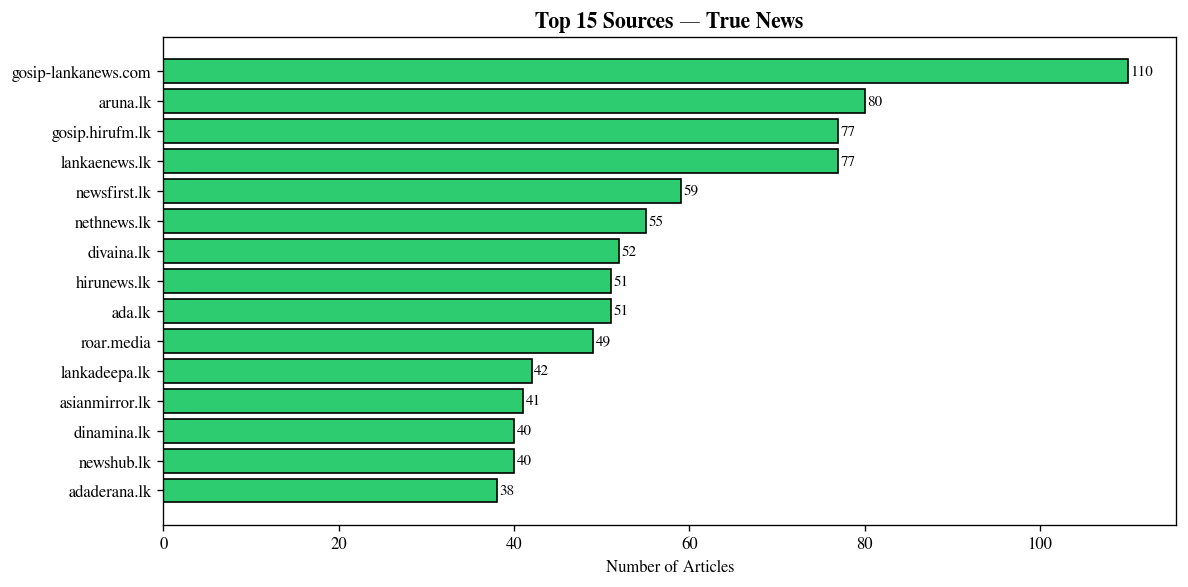

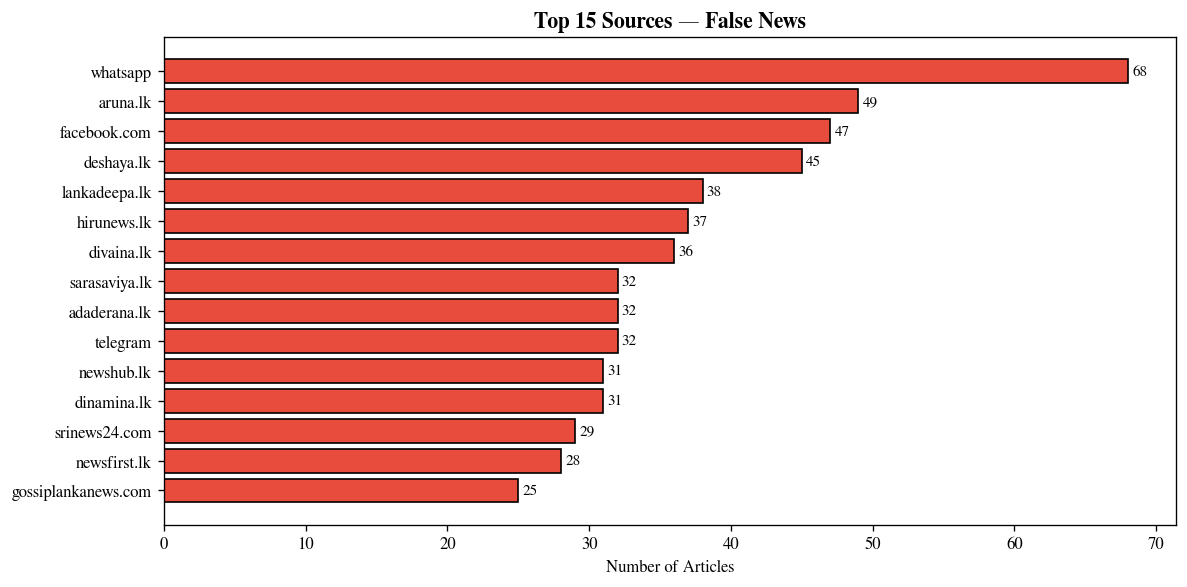

In [24]:
top_n = 15

for label, color in [('True News', '#2ecc71'), ('False News', '#e74c3c')]:
    subset = df[df['label'] == label]['source'].value_counts().head(top_n)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(subset.index[::-1], subset.values[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top {top_n} Sources — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Articles')
    for bar, val in zip(bars, subset.values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

Unique sources in True News  : 27
Unique sources in False News : 39
Sources appearing in BOTH    : 25

Overlapping sources: ['ada.lk', 'adaderana.lk', 'anidda.lk', 'aruna.lk', 'asianmirror.lk', 'bbc.com/sinhala', 'deshaya.lk', 'dinamina.lk', 'divaina.lk', 'gosip-lankanews.com', 'gosip.hirufm.lk', 'gossiplankanews.com', 'hirunews.lk', 'lankacnews.com', 'lankadeepa.lk', 'lankaenews.lk', 'nethnews.lk', 'newsfirst.lk', 'newshub.lk', 'praja.lk', 'ravaya.lk', 'roar.media', 'samabima.com', 'sarasaviya.lk', 'vikalpa.org']


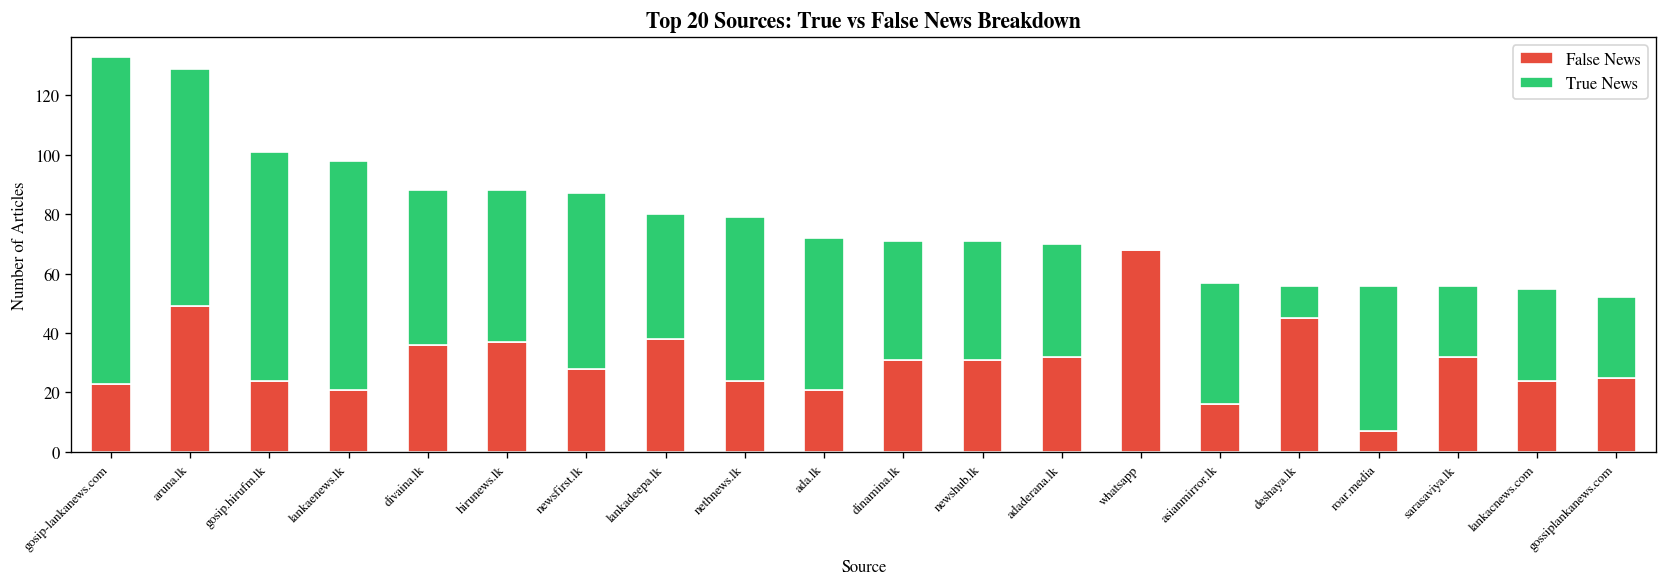

In [25]:
# Sources that appear in both true and false news
true_sources  = set(df[df['label'] == 'True News']['source'].dropna().unique())
false_sources = set(df[df['label'] == 'False News']['source'].dropna().unique())
overlap = true_sources & false_sources

print(f"Unique sources in True News  : {len(true_sources)}")
print(f"Unique sources in False News : {len(false_sources)}")
print(f"Sources appearing in BOTH    : {len(overlap)}")
print("\nOverlapping sources:", sorted(overlap))

# Stacked bar: top 20 sources with true/false split
all_sources = df.groupby(['source', 'label']).size().unstack(fill_value=0)
all_sources['total'] = all_sources.sum(axis=1)
top20 = all_sources.nlargest(20, 'total').drop(columns='total')

top20.plot(kind='bar', stacked=True, figsize=(14, 5),
           color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('Top 20 Sources: True vs False News Breakdown', fontsize=13, fontweight='bold')
plt.xlabel('Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Character-level Analysis (Sinhala Unicode)

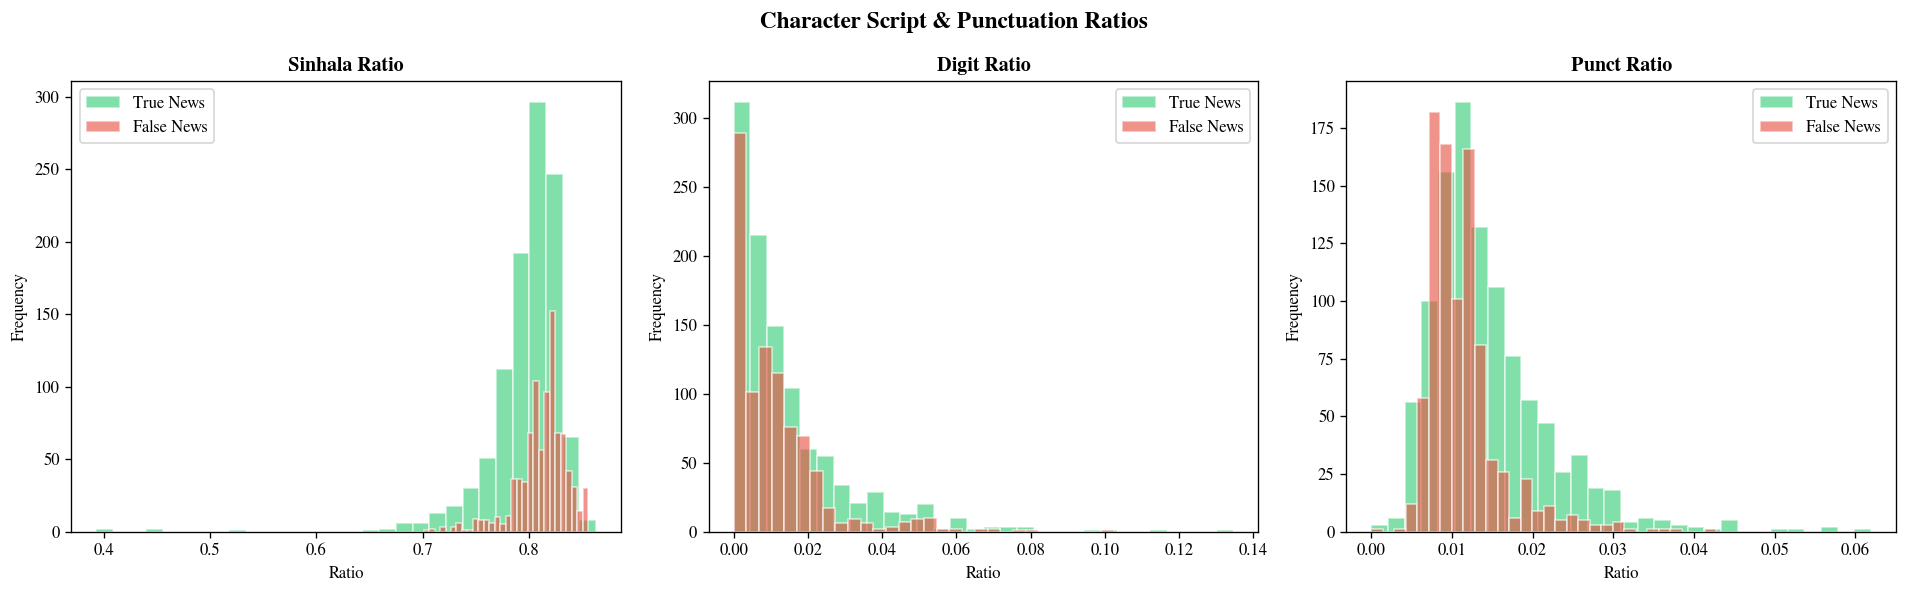


Mean feature values by class:
            sinhala_ratio  digit_ratio  punct_ratio
label                                              
False News         0.8128       0.0112       0.0114
True News          0.7978       0.0140       0.0145


In [26]:
def script_ratio(text):
    """Return ratio of Sinhala characters (U+0D80–U+0DFF) to total chars."""
    sinhala = sum(1 for c in text if '\u0D80' <= c <= '\u0DFF')
    return sinhala / max(len(text), 1)

def digit_ratio(text):
    digits = sum(1 for c in text if c.isdigit())
    return digits / max(len(text), 1)

def punct_ratio(text):
    puncts = sum(1 for c in text if c in '.,!?;:\'\"()[]{}')
    return puncts / max(len(text), 1)

df['sinhala_ratio'] = df['content'].apply(script_ratio)
df['digit_ratio']   = df['content'].apply(digit_ratio)
df['punct_ratio']   = df['content'].apply(punct_ratio)

features = ['sinhala_ratio', 'digit_ratio', 'punct_ratio']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, features):
    for label, color in [('True News', '#2ecc71'), ('False News', '#e74c3c')]:
        ax.hist(df[df['label'] == label][feat], bins=30, alpha=0.6,
                label=label, color=color, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Ratio')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Character Script & Punctuation Ratios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMean feature values by class:")
print(df.groupby('label')[features].mean().round(4))

## 5. Feature Correlation Heatmap

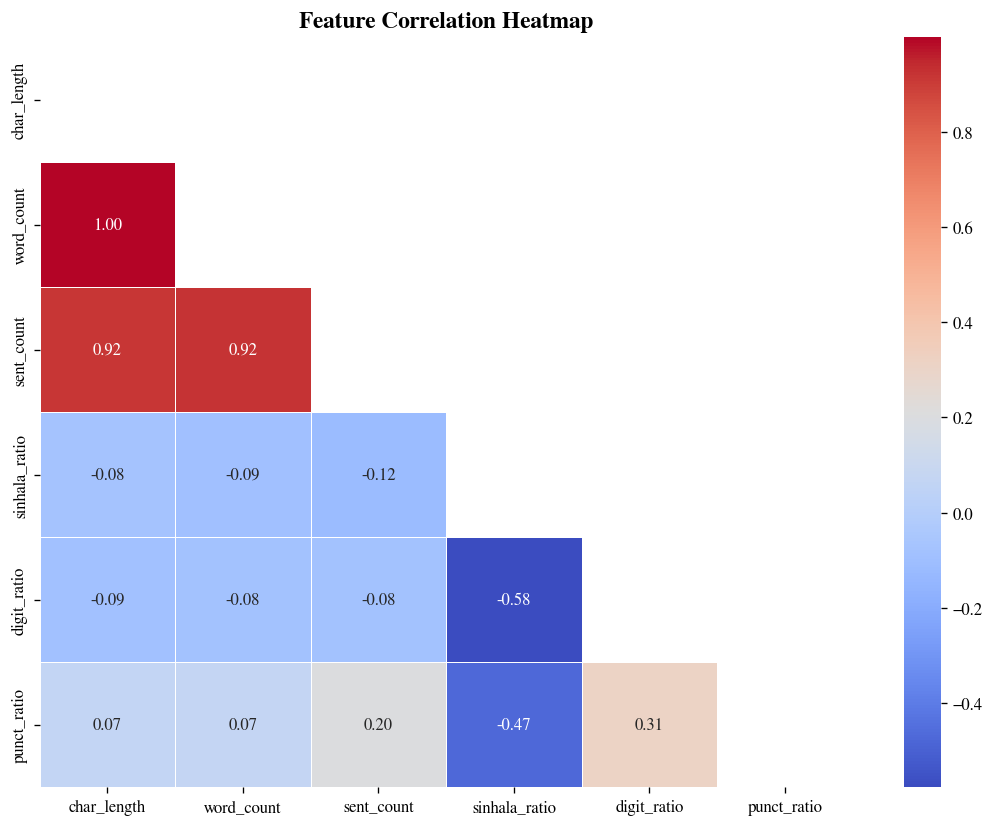

In [27]:
num_features = ['char_length', 'word_count', 'sent_count',
                'sinhala_ratio', 'digit_ratio', 'punct_ratio']

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Sinhala Stopwords Definition

Common Sinhala function words to filter out before token-level analysis below.

In [28]:
# ── Sinhala stopwords ──────────────────────────────────────────────────────────
SINHALA_STOPWORDS = {
    'සහ', 'හා', 'හෝ', 'නමුත්', 'එහෙත්', 'නිසා', 'බැවින්', 'නම්',
    'මෙම', 'ඒ', 'එම', 'එය', 'මෙය', 'ඔහු', 'ඇය', 'ඔවුන්', 'ඔවුහු',
    'ඔහුගේ', 'ඇගේ', 'ඔවුන්ගේ', 'මෙහි', 'එහි', 'මෙතැන', 'එතැන',
    'ද', 'ම', 'ත්', 'වෙත', 'විසින්', 'සඳහා', 'අතර', 'පිළිබඳ', 'ලෙස',
    'ලෙසම', 'ලෙසින්', 'කෙසේ', 'යනු', 'යන', 'බව', 'යයි', 'කිව',
    'වේ', 'වෙයි', 'ඇත', 'නැත', 'ඇති', 'නැති', 'විය', 'වී', 'කර', 'කළ',
    'කරයි', 'කරනු', 'කරන', 'ලබා', 'ලැබී', 'ලැබෙන', 'දී', 'ගෙන', 'ගොස්',
    'තුළ', 'සිට', 'දක්වා', 'පිට', 'අනුව', 'යටතේ', 'හරහා',
    'එකක්', 'දෙකක්', 'කිහිපයක්', 'සියලු', 'සෑම', 'ඇතැම්', 'බොහෝ',
    'කවුද', 'කුමක්ද', 'කොතෙකද', 'කෙසේද', 'ඇයි', 'කවදා',
    'මෙලෙස', 'ඒ්', 'වන', 'වූ', 'යැයි', 'ඉදිරිපත්', 'ප්‍රකාශ', 'ප්', 'ක්', 'රී', 'ශ්', 'මේ',
}

print(f"Loaded {len(SINHALA_STOPWORDS)} Sinhala stopwords")

Loaded 92 Sinhala stopwords


## 6. Most Common Sinhala Words (Top Unigrams)

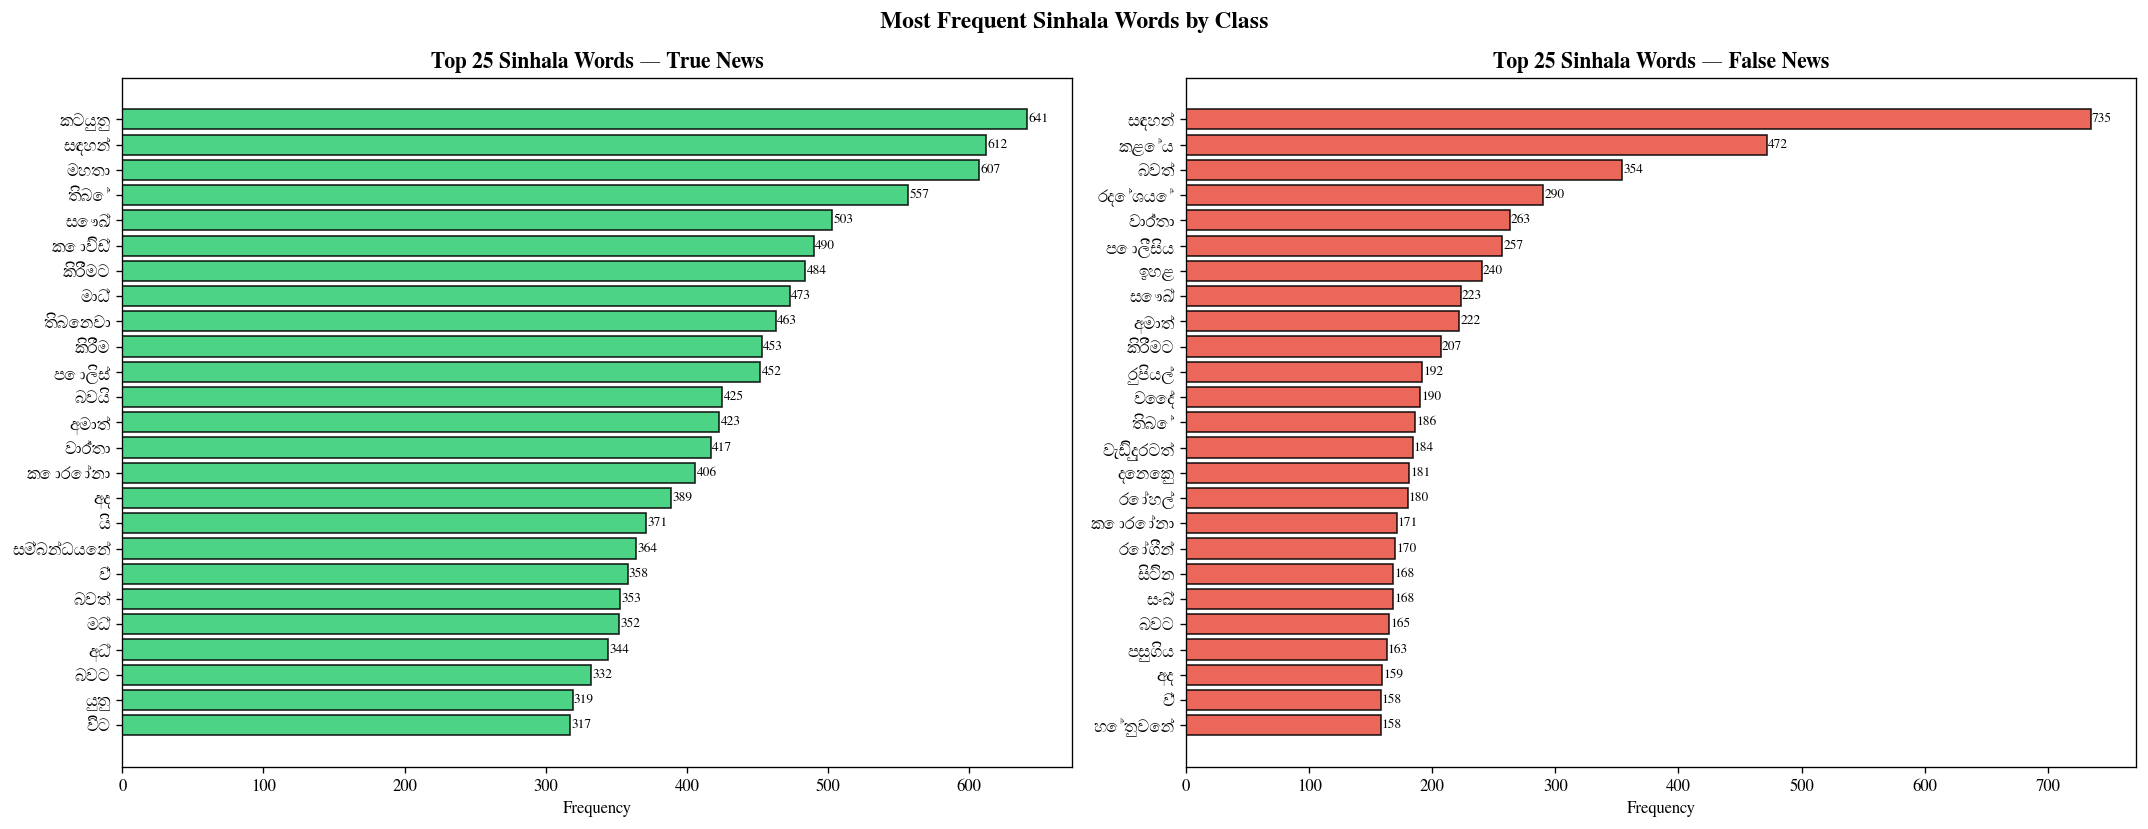

In [29]:
def get_sinhala_tokens(texts, top_n=30, stopwords=None):
    """Extract Sinhala-script tokens only, optionally filtering out stopwords."""
    all_tokens = []
    for text in texts:
        tokens = re.findall(r'[\u0D80-\u0DFF]+', text)
        for t in tokens:
            if len(t) < 2:
                continue
            if stopwords and t in stopwords:
                continue
            all_tokens.append(t)
    return Counter(all_tokens).most_common(top_n)

# FontProperties with a Sinhala-supporting font for y-tick labels
sinhala_font = fm.FontProperties(family='FreeSerif', size=10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (label, color) in zip(axes, [('True News', '#2ecc71'), ('False News', '#e74c3c')]):
    texts = df[df['label'] == label]['content'].tolist()
    top_words = get_sinhala_tokens(texts, top_n=25, stopwords=SINHALA_STOPWORDS)
    words, freqs = zip(*top_words)
    
    bars = ax.barh(range(len(words)), freqs, color=color, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10, fontproperties=sinhala_font)
    ax.invert_yaxis()
    ax.set_title(f'Top 25 Sinhala Words — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, freq in zip(bars, freqs):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(freq), va='center', fontsize=8)

plt.suptitle('Most Frequent Sinhala Words by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
for label in ['True News', 'False News']:
    texts = df[df['label'] == label]['content'].tolist()
    top_words = get_sinhala_tokens(texts, top_n=25, stopwords=SINHALA_STOPWORDS)

    print(f"\n{'='*50}")
    print(f"Top 25 Sinhala Words — {label}")
    print(f"{'='*50}")

    for rank, (word, freq) in enumerate(top_words, start=1):
        print(f"{rank:2d}. {word:<20} {freq}")


Top 25 Sinhala Words — True News
 1. කටයුතු               641
 2. සඳහන්                612
 3. මහතා                 607
 4. තිබේ                 557
 5. සෞඛ්                 503
 6. කොවිඩ්               490
 7. කිරීමට               484
 8. මාධ්                 473
 9. තිබෙනවා              463
10. කිරීම                453
11. පොලිස්               452
12. බවයි                 425
13. අමාත්                423
14. වාර්තා               417
15. කොරෝනා               406
16. අද                   389
17. යි                   371
18. සම්බන්ධයෙන්          364
19. ව්                   358
20. බවත්                 353
21. මධ්                  352
22. අධ්                  344
23. බවට                  332
24. යුතු                 319
25. විට                  317

Top 25 Sinhala Words — False News
 1. සඳහන්                735
 2. කළේය                 472
 3. බවත්                 354
 4. රදේශයේ               290
 5. වාර්තා               263
 6. පොලීසිය              257
 7. ඉහළ                  240
 8.

## 7. Exclusive Words: True-only vs False-only

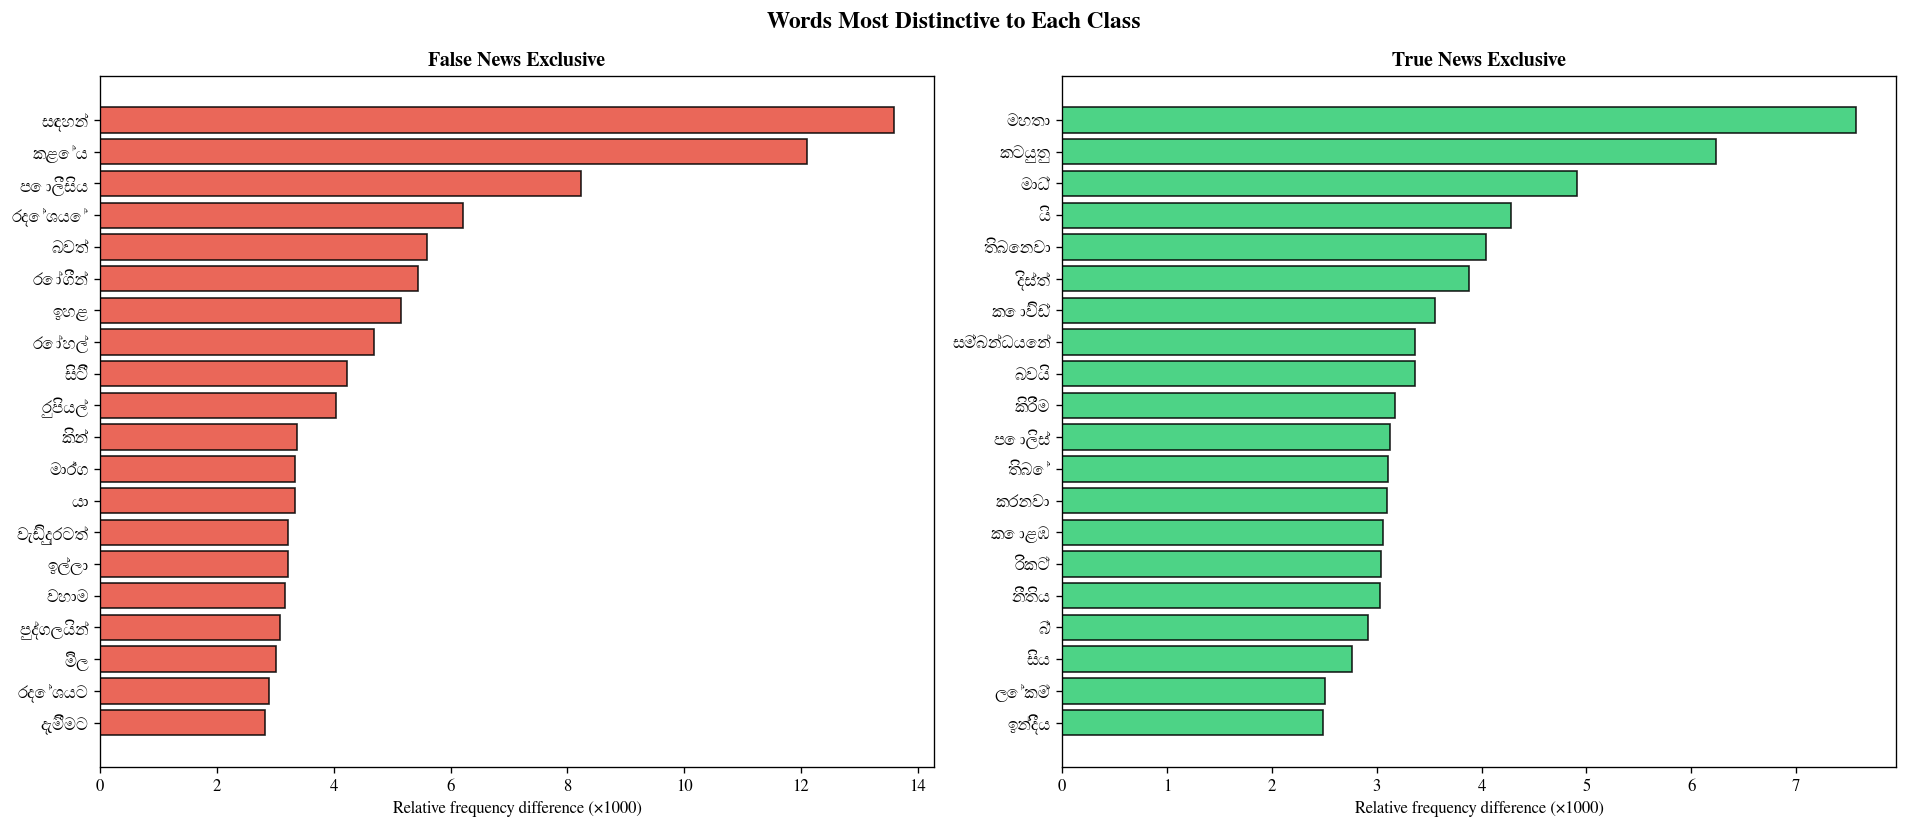

In [31]:
true_counter  = Counter(dict(get_sinhala_tokens(df[df['label']=='True News']['content'].tolist(), top_n=500, stopwords=SINHALA_STOPWORDS)))
false_counter = Counter(dict(get_sinhala_tokens(df[df['label']=='False News']['content'].tolist(), top_n=500, stopwords=SINHALA_STOPWORDS)))

# Words that appear far more in one class (relative frequency diff)
true_vocab  = set(true_counter.keys())
false_vocab = set(false_counter.keys())

true_total  = sum(true_counter.values())
false_total = sum(false_counter.values())

scores = {}
all_words = true_vocab | false_vocab
for w in all_words:
    tf = true_counter.get(w, 0) / true_total
    ff = false_counter.get(w, 0) / false_total
    scores[w] = tf - ff   # positive → more in True, negative → more in False

sorted_scores = sorted(scores.items(), key=lambda x: x[1])
top_false_excl = sorted_scores[:20]   # most False-exclusive
top_true_excl  = sorted_scores[-20:]  # most True-exclusive

sinhala_font = fm.FontProperties(family='FreeSerif', size=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, label, color in [
        (axes[0], top_false_excl[::-1], 'False News Exclusive', '#e74c3c'),
        (axes[1], top_true_excl,        'True News Exclusive',  '#2ecc71')]:
    words, vals = zip(*data)
    ax.barh(words, [abs(v)*1000 for v in vals], color=color, edgecolor='black', alpha=0.85)
    ax.set_yticklabels(words, fontproperties=sinhala_font)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Relative frequency difference (×1000)')

plt.suptitle('Words Most Distinctive to Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Statistics Table

In [32]:
summary = df.groupby('label').agg(
    articles        = ('content', 'count'),
    unique_sources  = ('source', 'nunique'),
    avg_chars       = ('char_length', 'mean'),
    median_chars    = ('char_length', 'median'),
    avg_words       = ('word_count', 'mean'),
    avg_sinhala_pct = ('sinhala_ratio', lambda x: x.mean() * 100),
).round(1)

summary.columns = ['# Articles', 'Unique Sources', 'Avg Chars', 'Median Chars',
                   'Avg Words', 'Avg Sinhala %']
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(summary.to_string())
print("=" * 70)

DATASET SUMMARY
            # Articles  Unique Sources  Avg Chars  Median Chars  Avg Words  Avg Sinhala %
label                                                                                    
False News         908              39      528.8         245.0       81.1           81.3
True News         1052              27     1055.4         602.5      160.7           79.8


## 9. Cohen's Kappa — Inter-Annotator Agreement

Following the annotation protocol described in the proposal (Section 7.3), **3 fluent Sinhala speakers** (annotaters A1, A2, A3) independently labeled a representative sample of **220 articles** (110 TRUE + 110 FALSE, randomly sampled and shuffled).

Each annotater classified articles as:
- **TRUE**: The content is factual and matches credible sources
- **FALSE**: The content is demonstrably false or contradicts reliable evidence

Annotaters worked independently (blinded) to avoid influencing each other's judgments.

Cohen's Kappa κ is then computed for **every pair** of human annotaters. The minimum acceptable threshold for substantial agreement is **κ ≥ 0.61**.

In [33]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

# ── Load the human-annotated sample ──────────────────────────────────────────
sample_df = pd.read_csv('annotated_data.csv')

# Map TRUE/FALSE (boolean or string) to numeric: 1 = True News, 0 = False News
def to_numeric(val):
    if isinstance(val, bool):
        return int(val)
    s = str(val).strip().upper()
    return 1 if s in ('TRUE', '1', 'YES') else 0

annotaters = {
    'Annotator A1': sample_df['annotater1'].apply(to_numeric).values,
    'Annotator A2': sample_df['annotater2'].apply(to_numeric).values,
    'Annotator A3': sample_df['annotater3'].apply(to_numeric).values,
}

annotater_names = list(annotaters.keys())
n = len(annotater_names)

# ── Per-annotater label distribution ─────────────────────────────────────────
print("=" * 55)
print("LABEL DISTRIBUTION PER ANNOTATER")
print("=" * 55)
for name in annotater_names:
    vals = annotaters[name]
    n_true = vals.sum()
    n_false = len(vals) - n_true
    print(f"  {name:20s}  TRUE: {n_true:3d}   FALSE: {n_false:3d}")

# ── Compute pairwise Cohen's Kappa ──────────────────────────────────────────
kappa_matrix = pd.DataFrame(np.nan, index=annotater_names, columns=annotater_names)

for a1, a2 in combinations(annotater_names, 2):
    k = cohen_kappa_score(annotaters[a1], annotaters[a2])
    kappa_matrix.loc[a1, a2] = round(k, 4)
    kappa_matrix.loc[a2, a1] = round(k, 4)

for name in annotater_names:
    kappa_matrix.loc[name, name] = 1.0

print("\nCohen's Kappa Matrix (human annotater pairs):\n")
print(kappa_matrix.to_string())
print()

# ── Overall agreement stats ──────────────────────────────────────────────────
all_agree = sum(
    1 for i in range(len(sample_df))
    if (annotaters['Annotator A1'][i] == annotaters['Annotator A2'][i] == annotaters['Annotator A3'][i])
)
pairwise_agreements = []
for a1, a2 in combinations(annotater_names, 2):
    same = (annotaters[a1] == annotaters[a2]).sum()
    pairwise_agreements.append((f'{a1} ↔ {a2}', same / len(sample_df)))

print(f"Full agreement (all 3 annotaters): {all_agree} / {len(sample_df)} ({100*all_agree/len(sample_df):.1f}%)")
for pair, pct in pairwise_agreements:
    print(f"  {pair:40s} {100*pct:.1f}%")

# ── Interpretation guide ─────────────────────────────────────────────────────
print()
print("Kappa interpretation guide:")
print("  < 0.00  → Poor agreement")
print("  0.00–0.20 → Slight")
print("  0.21–0.40 → Fair")
print("  0.41–0.60 → Moderate")
print("  0.61–0.80 → Substantial")
print("  0.81–1.00 → Almost perfect")

LABEL DISTRIBUTION PER ANNOTATER
  Annotator A1          TRUE: 170   FALSE: 156
  Annotator A2          TRUE: 166   FALSE: 160
  Annotator A3          TRUE: 169   FALSE: 157

Cohen's Kappa Matrix (human annotater pairs):

              Annotator A1  Annotator A2  Annotator A3
Annotator A1        1.0000        0.9263        0.9693
Annotator A2        0.9263        1.0000        0.9325
Annotator A3        0.9693        0.9325        1.0000

Full agreement (all 3 annotaters): 312 / 326 (95.7%)
  Annotator A1 ↔ Annotator A2              96.3%
  Annotator A1 ↔ Annotator A3              98.5%
  Annotator A2 ↔ Annotator A3              96.6%

Kappa interpretation guide:
  < 0.00  → Poor agreement
  0.00–0.20 → Slight
  0.21–0.40 → Fair
  0.41–0.60 → Moderate
  0.61–0.80 → Substantial
  0.81–1.00 → Almost perfect


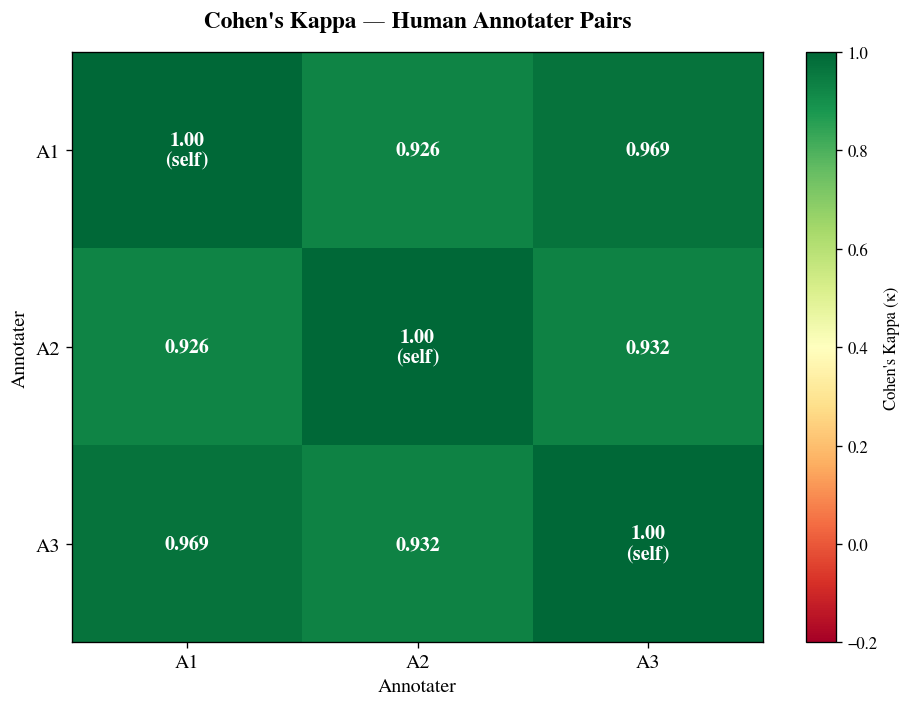

In [34]:
# ── Heatmap of Kappa values ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

short_labels = ['A1', 'A2', 'A3']
kappa_vals = kappa_matrix.values.astype(float)

im = ax.imshow(kappa_vals, cmap='RdYlGn', vmin=-0.2, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label="Cohen's Kappa (κ)")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, fontsize=12)
ax.set_yticklabels(short_labels, fontsize=12)
ax.set_title("Cohen's Kappa — Human Annotater Pairs", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annotater', fontsize=12)
ax.set_ylabel('Annotater', fontsize=12)

for i in range(n):
    for j in range(n):
        val = kappa_vals[i, j]
        if not np.isnan(val):
            text_color = 'black' if 0.3 < val < 0.8 else 'white'
            label = '1.00\n(self)' if i == j else f'{val:.3f}'
            ax.text(j, i, label, ha='center', va='center',
                    fontsize=12, fontweight='bold', color=text_color)

plt.tight_layout()
plt.show()

In [35]:
# ── Pairwise kappa table sorted by agreement ─────────────────────────────────
rows = []
for a1, a2 in combinations(annotater_names, 2):
    k = kappa_matrix.loc[a1, a2]
    if k < 0.00:     interp = 'Poor'
    elif k < 0.20:   interp = 'Slight'
    elif k < 0.40:   interp = 'Fair'
    elif k < 0.60:   interp = 'Moderate'
    elif k < 0.80:   interp = 'Substantial'
    else:            interp = 'Almost Perfect'
    rows.append({'Pair': f'{a1}  ↔  {a2}', 'κ': round(k, 4), 'Interpretation': interp})

kappa_df = pd.DataFrame(rows).sort_values('κ', ascending=False).reset_index(drop=True)
print("Pairwise Cohen's Kappa (sorted by agreement):\n")
print(kappa_df.to_string(index=False))

print("\n" + "=" * 60)
print("THRESHOLD CHECK")
print("=" * 60)
print(f"Minimum required (κ ≥ 0.61): {'✓ MET' if kappa_df['κ'].min() >= 0.61 else '✗ NOT MET'}")
print(f"Highest κ: {kappa_df['κ'].max():.4f}")
print(f"Lowest  κ: {kappa_df['κ'].min():.4f}")
print(f"Average κ: {kappa_df['κ'].mean():.4f}")

# ── Resolve disagreements + create ground truth ─────────────────────────────
print("\n" + "=" * 60)
print("GROUND TRUTH — MAJORITY VOTE RECONCILIATION")
print("=" * 60)

a1_arr = annotaters['Annotator A1']
a2_arr = annotaters['Annotator A2']
a3_arr = annotaters['Annotator A3']

# Majority vote: sum ≥ 2 → TRUE (1), else → FALSE (0)
majority_label = ((a1_arr + a2_arr + a3_arr) >= 2).astype(int)

disagreements = np.where(~((a1_arr == a2_arr) & (a2_arr == a3_arr)))[0]
print(f"Articles with annotater disagreement: {len(disagreements)} / {len(sample_df)}")

if len(disagreements) > 0:
    print("\nDisagreement details (showing first 5):")
    for idx in disagreements[:5]:
        print(f"  Row {idx}: A1={a1_arr[idx]}, A2={a2_arr[idx]}, A3={a3_arr[idx]} → Majority: {majority_label[idx]}")

print(f"\nFinal ground truth distribution:")
n_true_gt = majority_label.sum()
n_false_gt = len(majority_label) - n_true_gt
print(f"  TRUE (real news) : {n_true_gt}")
print(f"  FALSE (fake news): {n_false_gt}")

# ── Save reconciled labels back to annotated_data.csv ───────────────────────
sample_df['ground_truth'] = majority_label
sample_df['ground_truth_label'] = np.where(majority_label == 1, 'TRUE', 'FALSE')
sample_df.to_csv('annotated_data.csv', index=False)
print(f"\n✓ Reconciled ground truth saved to annotated_data.csv")

Pairwise Cohen's Kappa (sorted by agreement):

                         Pair      κ Interpretation
Annotator A1  ↔  Annotator A3 0.9693 Almost Perfect
Annotator A2  ↔  Annotator A3 0.9325 Almost Perfect
Annotator A1  ↔  Annotator A2 0.9263 Almost Perfect

THRESHOLD CHECK
Minimum required (κ ≥ 0.61): ✓ MET
Highest κ: 0.9693
Lowest  κ: 0.9263
Average κ: 0.9427

GROUND TRUTH — MAJORITY VOTE RECONCILIATION
Articles with annotater disagreement: 14 / 326

Disagreement details (showing first 5):
  Row 13: A1=1, A2=1, A3=0 → Majority: 1
  Row 24: A1=1, A2=0, A3=1 → Majority: 1
  Row 36: A1=1, A2=0, A3=1 → Majority: 1
  Row 58: A1=1, A2=0, A3=1 → Majority: 1
  Row 92: A1=1, A2=0, A3=1 → Majority: 1

Final ground truth distribution:
  TRUE (real news) : 171
  FALSE (fake news): 155

✓ Reconciled ground truth saved to annotated_data.csv
